# 1. Load Dynamo & Data

In [2]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="numpy.dtype size changed")

import dynamo as dyn

dyn.configuration.set_figure_params('dynamo', background='white')
dyn.pl.style(font_path='Arial')
dyn.get_all_dependencies_version()

%load_ext autoreload
%autoreload 2

Using already downloaded Arial font from: /var/folders/_0/8l2kpxvj13b9xcgqzjm3mkjw0000gn/T/dynamo_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered custom font as: Arial


 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



package,ipykernel,numpy,setuptools,Pygments,igraph,datacache,tqdm,pynndescent,adjustText,networkx,umap-learn,pandas,get_version,mudata,dynamo-release,patsy,colorcet,numpy,numba,loompy,scikit-learn,seaborn,leidenalg,openpyxl,statsmodels,anndata,matplotlib,numdifftools,scipy,requests
version,6.30.1,2.0.2,80.9.0,2.19.1,1.0.0,1.4.1,4.67.3,0.6.0,1.3.0,3.2.1,0.5.11,2.3.3,3.5.5,0.2.4,1.5.2,1.0.2,3.1.0,2.0.2,0.60.0,3.0.8,1.6.1,0.13.2,0.11.0,3.1.5,0.14.6,0.10.9,3.9.4,0.9.41,1.13.1,2.32.5


In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse
import anndata as ad

In [20]:
def process_adata(path):
    adata = dyn.read(path)
    
    # Drop duplicate gene symbols and modify for Dynamo format
    symbols = adata.var["gene_symbols"].astype(str).values
    unique_symbols, index_inverse = np.unique(symbols, return_inverse=True)
    
    # Summing matrix: original genes x unique genes
    # This is a sparse matrix of 1s that tells the computer which rows to sum
    row = np.arange(len(symbols))
    col = index_inverse
    data = np.ones(len(symbols))
    S = sparse.csr_matrix((data, (row, col)), shape=(len(symbols), len(unique_symbols)))

    # Take the first occurrence of each symbol to keep metadata (like chromosome)
    _, first_indices = np.unique(symbols, return_index=True)
    var_unique = adata.var.iloc[first_indices].copy()
    var_unique.index = symbols[first_indices]
    var_unique.index.name = None
    
    # cells x genes) @ (genes x unique genes)
    new_X = adata.X @ S
    
    new_adata = ad.AnnData(X=new_X, obs=adata.obs.copy(), var=var_unique)
    
    for layer in ['spliced', 'unspliced']:
        if layer in adata.layers:
            new_adata.layers[layer] = adata.layers[layer] @ S
            
    print(new_adata)
    return new_adata

files = ['SRX21172619.h5ad', 'SRX23456399.h5ad', 'SRX21788827.h5ad', 'SRX21788830.h5ad']
adata_list = [process_adata(f) for f in files]
adata = ad.concat(adata_list, join='inner', label='condition', 
                  keys=['Control', 'NMDA 36hrs', 'NMDA 72hrs', 'NMDA 96hrs'])
print("Concatenated adata:", adata) #17.7s

AnnData object with n_obs × n_vars = 16064 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 29896 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 27622 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id'
    var: 'gene_symbols'
    layers: 'spliced', 'unspliced'
AnnData object with n_obs × n_vars = 28182 × 25404
    obs: 'gene_coun

# 2. Preprocessing

In [35]:
dyn.pp.filter_cells(adata, filter_bool=adata.obs.gene_count_spliced + adata.obs.gene_count_unspliced > 200)
dyn.pp.filter_genes(adata, filter_bool=(adata.layers['spliced'] > 0).sum(axis=0).A1 + (adata.layers['unspliced'] > 0).sum(axis=0).A1 > 10)
adata.obs_names_make_unique()
adata.uns["pp"] = {}
dyn.pp.normalize_cell_expr_by_size_factors(adata)
dyn.pp.select_genes_monocle(adata)
dyn.pp.pca(adata)
# 20s

|-----------> filtered out 2123 outlier cells
|-----------> filtered out 10901 outlier genes
|-----> Set <adata.X> to normalized data
|-----> <insert> X_pca to obsm in AnnData Object.


AnnData object with n_obs × n_vars = 99641 × 25404
    obs: 'gene_count_spliced', 'umi_count_spliced', 'gene_count_ambiguous', 'umi_count_ambiguous', 'gene_count_unspliced', 'umi_count_unspliced', 'SRX_accession', 'cell_type', 'cell_ontology_term_id', 'condition', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size'
    var: 'pass_basic_filter', 'log_m', 'score', 'log_cv', 'frac', 'use_for_pca'
    uns: 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean'
    obsm: 'X_pca'
    layers: 'spliced', 'unspliced', 'X_spliced', 'X_unspliced'

In [37]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
# 10s

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [76]:
sc.tl.leiden(adata,
             resolution=0.4, # Larger values give more clusters
             flavor="igraph",
             n_iterations=2,
             directed=False,
             random_state=28,
)

In [80]:
sc.tl.umap(adata,
           min_dist=0.4) # The effective minimum distance between embedded points
                         # Smaller values will result in a more clustered/clumped embedding
# 30s

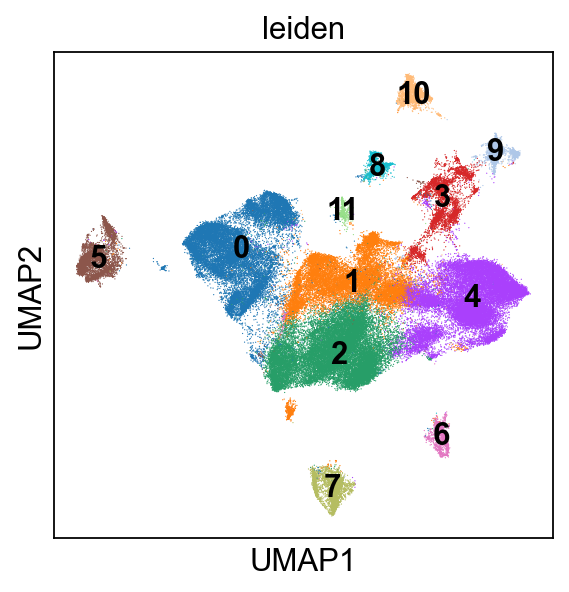

In [77]:
# Coarse cell clusters
sc.pl.umap(adata, 
           color="leiden", 
           legend_loc="on data")

# 3. Cell type annotations

In [87]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')
DEG = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
DEG.head(30)

,0,1,2,3,4,5,6,7,8,9,10,11
0,syt1a,cdh2,grin1b,prph2a,rho,SLC4A5,rgrb,grna,opn1sw2,opn1mw2,opn1sw1,hbba1
1,grin1a,mdka,slc12a5b,slc24a2,si:ch211-113d22.2,tnr,stra6,lgals3bp.1,prph2a,prph2a,ly6pge,hbaa1
2,sv2a,mt-atp6,zfhx4,opn1lw1,rom1b,pcdh8,rbp5,ctsc,rbp4l,clul1,prph2a,ba1l
3,gpm6aa,mt-co3,nova2,clul1,pde6gb,ENSDARG00000116725,tyrp1b,mrc1b,clul1,slc24a2,spock3,si:ch211-5k11.8
4,nrxn1a,fabp7a,aplp1,thrb,gnat1,mdka,rpe65a,cd74b,opn6b,rbp4l,clul1,ENSDARG00000092945
5,tkta,mt-co2,lrit1a,rbp4l,pde6b,vtnb,pmelb,psap,spock3,prph2b,fat1b,creg1
6,pclob,zbtb18,rs1a,hexb,cnga1a,atp1b1a,msnb,apoc1,prph2b,six7,opn6b,rplp0
7,slc32a1,si:dkey-151g10.6,nell2b,six7,gnb1a,slc12a2,pmela,ccl34b.1,slc24a2,atp6ap1lb,gnb3b,rpsa
8,elavl3,rtn4a,cabp5a,pde6c,gnb1b,clu,ambp,ctsba,arr3b,laptm4b,prph2b,epb41b
9,slc6a1b,mt-co1,vamp1a,prph2b,gngt1,rtn4r,tm6sf2b,cd74a,tmem237a,pde6c,zgc:193593,fth1a


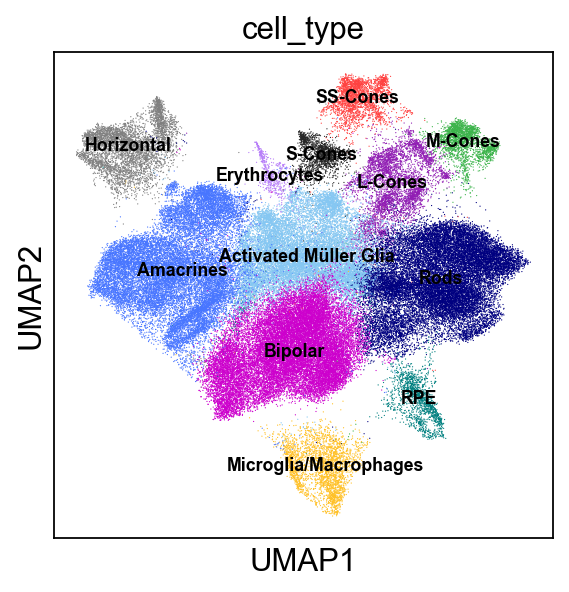

In [91]:
cluster_annotation = {
    "0": "Amacrines",
    "1": "Activated Müller Glia",
    "2": "Bipolar",
    "3": "L-Cones",
    "4": "Rods",
    "5": "Horizontal",
    "6": "RPE",
    "7": "Microglia/Macrophages",
    "8": "S-Cones",
    "9": "M-Cones",
    "10": "SS-Cones",
    "11": "Erythrocytes"
}

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_annotation)

sc.pl.umap(adata, color="cell_type", legend_loc="on data", legend_fontsize=8)

In [92]:
# Differntiate ganglion cells from amacrine cells
mixed_cells = adata[adata.obs['leiden'] == '0'].copy()

sc.pp.neighbors(mixed_cells, n_neighbors=10, n_pcs=20)
sc.tl.leiden(mixed_cells, 
             resolution=0.8, 
             flavor="igraph",
             n_iterations=2,
             directed=False,
             random_state=28,
             key_added='rgc_sub_leiden')

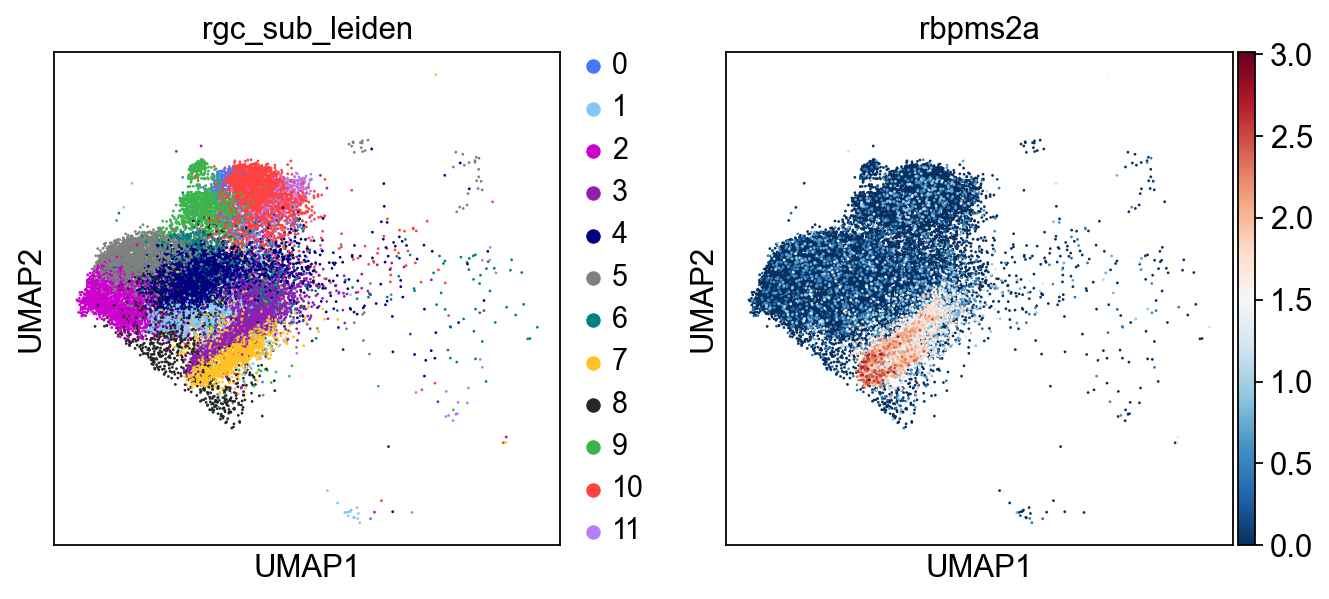

In [93]:
sc.pl.umap(mixed_cells, color=['rgc_sub_leiden', "rbpms2a"])

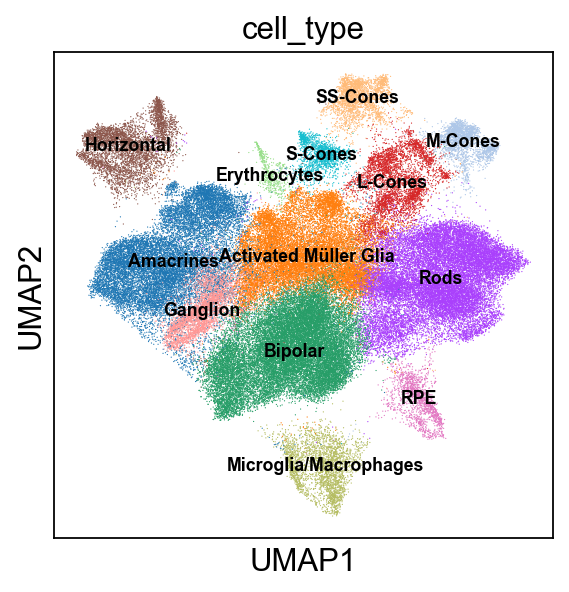

In [95]:
# Annotate Ganglion cells mislabeled as amacrine cells
adata.obs["cell_type"] = adata.obs["cell_type"].cat.add_categories(["Ganglion"])
adata.obs.loc[mixed_cells.obs.index[mixed_cells.obs["rgc_sub_leiden"].isin(["3", "7"])], "cell_type"] = "Ganglion"
sc.pl.umap(adata, color="cell_type", legend_loc="on data", legend_fontsize=8)

In [96]:
# Save results
adata.write('results/adata_celltype_annotated.h5ad')